In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

import skfuzzy as fuzz
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [30]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 3.Clusstering Fuzzy C-Means Algorithms

In [31]:
df = df.drop(columns='CustomerID')

In [32]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas") # Tambahkan baris ini sebelum fit_transform
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


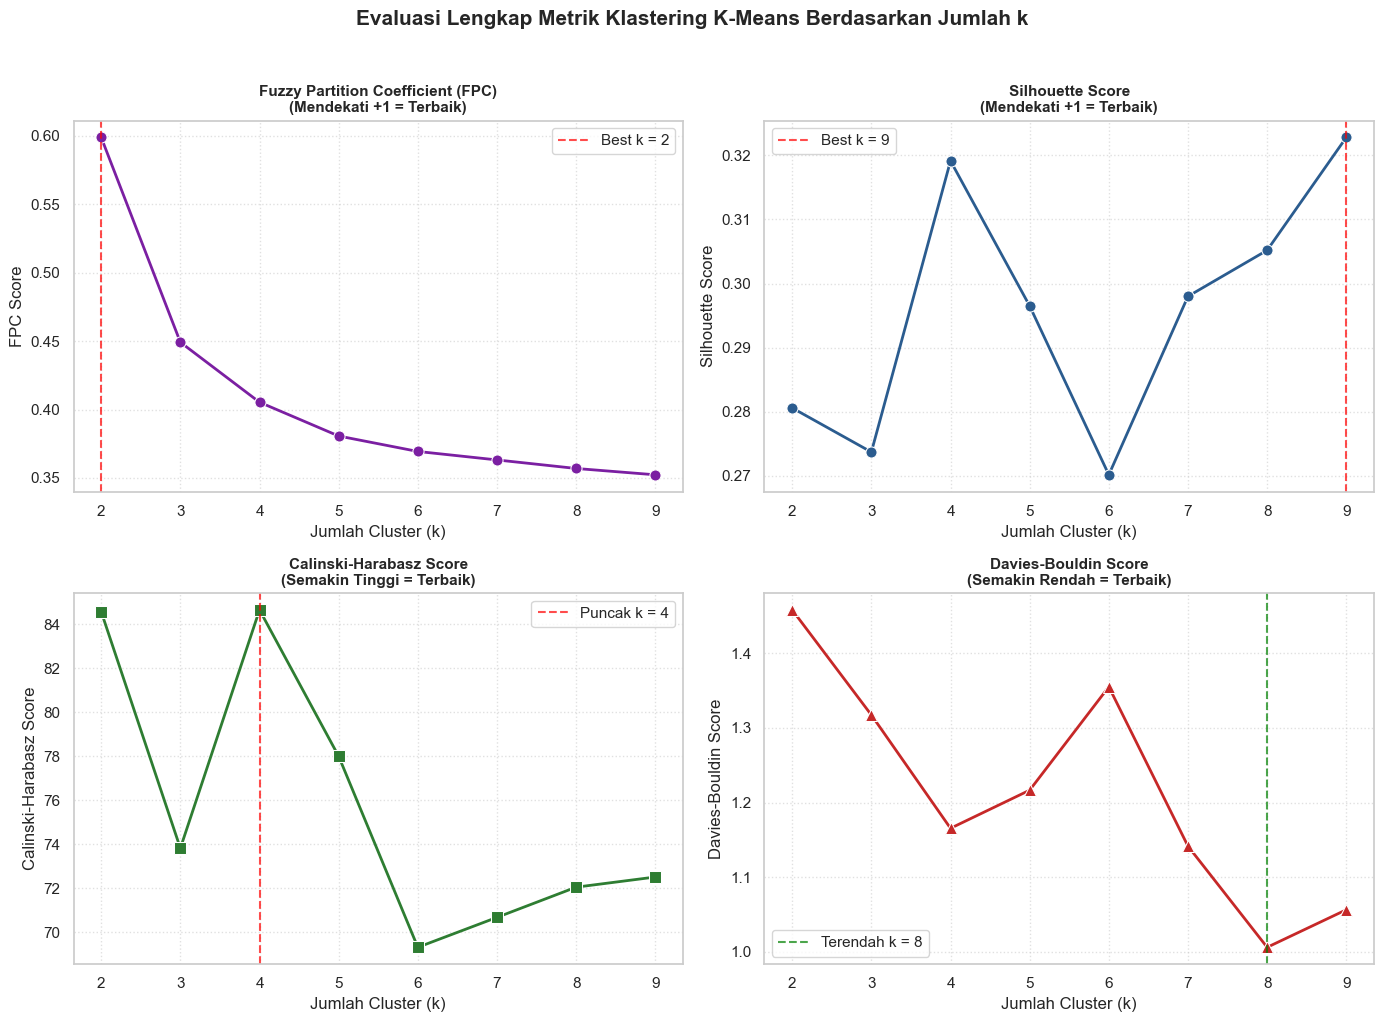

,n_clusters(k),FPC Score,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,2,0.598880,0.280604,84.572528,1.457867
1,3,0.449191,0.273724,73.827542,1.317224
2,4,0.405357,0.319119,84.652464,1.165554
3,5,0.380670,0.296499,78.003165,1.216556
4,6,0.369379,0.270180,69.327377,1.354961
5,7,0.363192,0.298003,70.686727,1.141612
6,8,0.356949,0.305184,72.058992,1.006253
7,9,0.352325,0.322780,72.519845,1.056494


In [ ]:
sil_scores = []
ch_scores = []
db_scores = []
fpc_scores = []
k_range = range(2, 10)

for k in k_range:
    cntr,u,u0,d,jm,p,fpc = fuzz.cluster.cmeans(X_cleaned.T,c=k,m=2.0,error=0.005,maxiter=1000,seed=42)
    fcm_labels = np.argmax(u,axis=0)
    # Hitung 4 metrik evaluasi
    sil_scores.append(silhouette_score(X_cleaned, fcm_labels))
    ch_scores.append(calinski_harabasz_score(X_cleaned, fcm_labels))
    db_scores.append(davies_bouldin_score(X_cleaned, fcm_labels))
    fpc_scores.append(fpc)

df_scores = pd.DataFrame({
    'n_clusters(k)': list(k_range),
    'FPC Score': fpc_scores,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fuzzy Partition Coefficient (FPC) -> Menggantikan Inertia
best_k_fpc = int(df_scores.loc[df_scores['FPC Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='FPC Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#7b1fa2')
axes[0, 0].axvline(x=best_k_fpc, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_fpc}')
axes[0, 0].set_title('Fuzzy Partition Coefficient (FPC)\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# Plot 2: Silhouette Score (Mendekati +1 Lebih Baik)
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 1].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# Plot 3: Calinski-Harabasz Score (Makin Tinggi Lebih Baik)
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[1, 0].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[1, 0].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# Plot 4: Davies-Bouldin Score (Makin Rendah Lebih Baik)
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 1], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 1].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 1].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Cluster (k)')
axes[1, 1].set_xticks(list(k_range))
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.suptitle('Evaluasi Lengkap Metrik Klastering Fuzzy C-Means Berdasarkan Jumlah k', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
df_scores

In [34]:
n_clusters = 4
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_cleaned.T,c=n_clusters,m=2.0,error=0.005,maxiter=1000,seed=42)
df['Cluster'] = np.argmax(u, axis=0)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,2
1,Male,21,15,81,2
2,Female,20,16,6,2
3,Female,23,16,77,2
4,Female,31,17,40,2


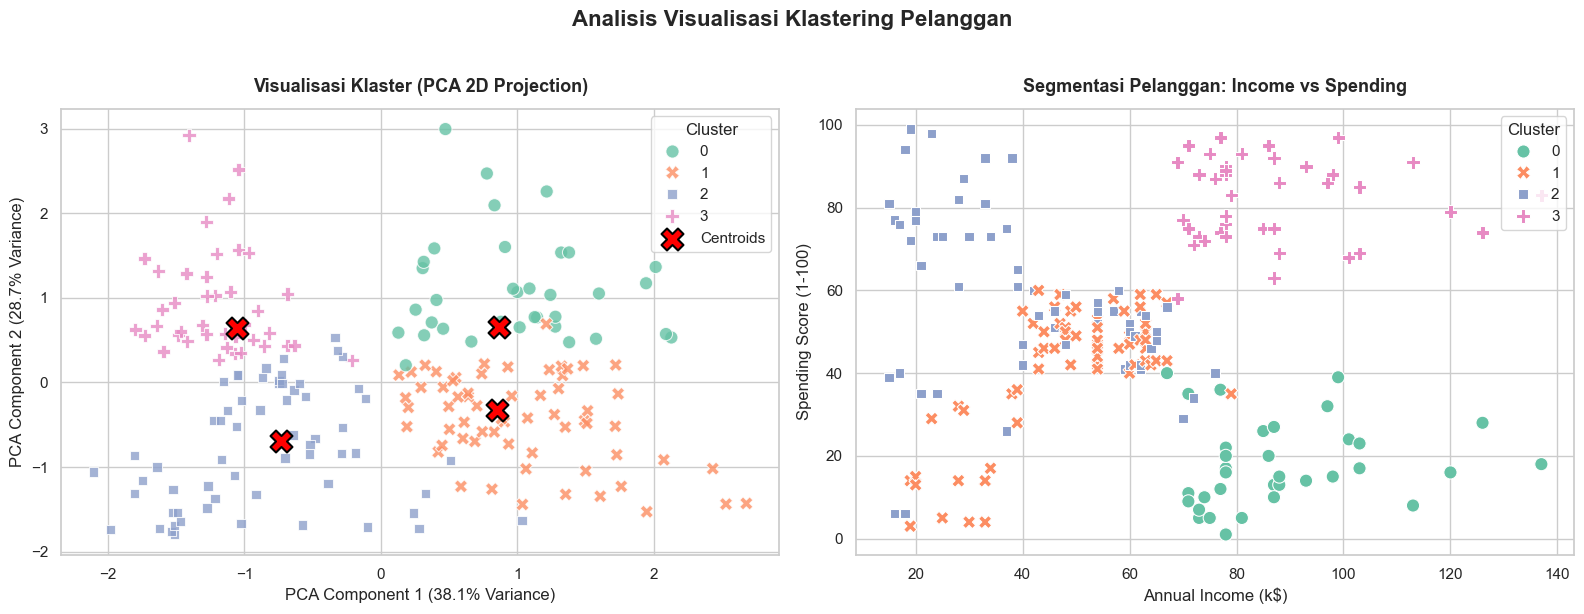

In [35]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']
centroids_pca = pca.transform(cntr)

sns.set_theme(style="whitegrid")
palette = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid
axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Cluster', loc='upper right')

sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,  palette=palette, s=90, style='Cluster')
axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(title='Cluster', loc='upper right')

plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

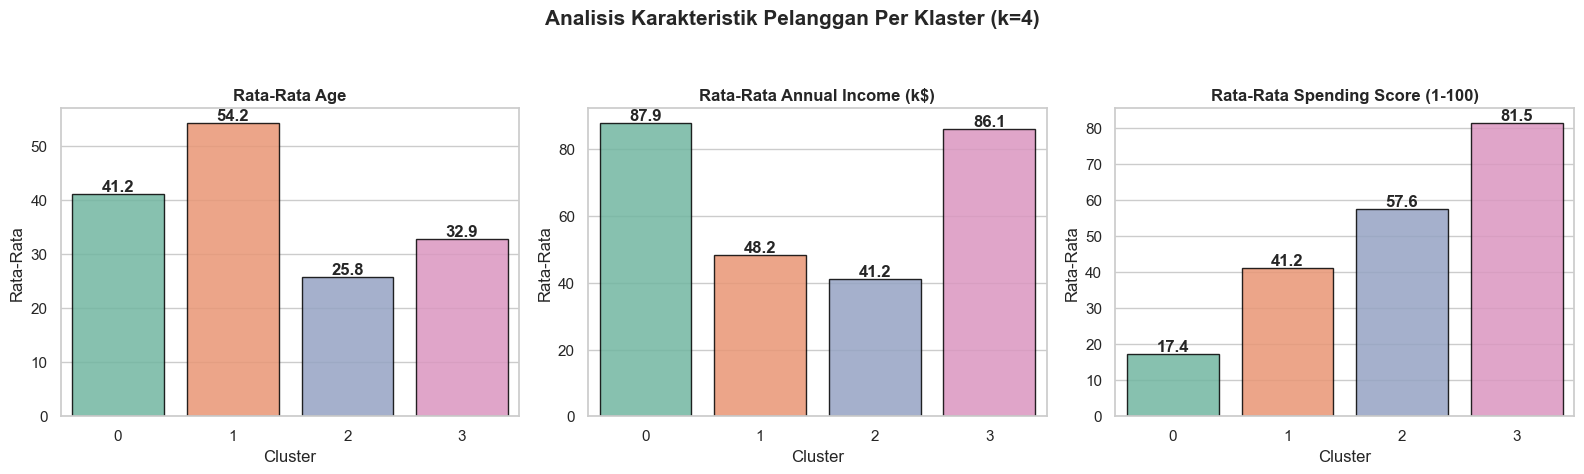

In [36]:
df_profile = df.groupby('Cluster')[num_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=palette, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-Rata')
    for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
        axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle('Analisis Karakteristik Pelanggan Per Klaster (k=4)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()